In [2]:
import xarray as xr
import numpy as np
from scipy.stats import binned_statistic

import matplotlib.pyplot as plt

In [3]:
ds_train = xr.open_zarr("/libre/finnt/data/teaching/wb2_train.zarr")["geopotential"]

In [4]:
ds_sliced = ds_train.sel(latitude=50, method="nearest").isel(var_name=0).load()

In [5]:
norm = 1 / 64
xc = np.ogrid[np.s_[-32:32]]
radius = np.sqrt(xc**2).round()
r_range = np.arange(33)
freqs = np.fft.fftfreq(64, 1)[:32]

In [6]:
psd = np.fft.fftshift(np.fft.fft(ds_sliced.values, axis=1))
psd = np.abs(psd)**2 / 64
psd = np.stack([binned_statistic(
    radius.flatten(), sub_psd.flatten(), bins=r_range-0.5
).statistic for sub_psd in psd], axis=0)

In [7]:
psd.shape

(56980, 32)

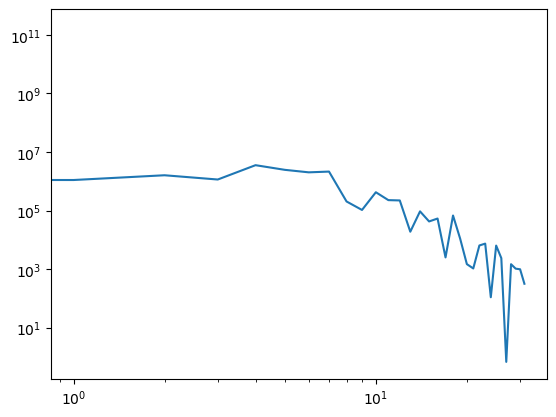

In [8]:
fig, ax = plt.subplots()
ax.loglog(psd[0])

In [9]:
avg_psd = np.exp(np.log(psd).mean(axis=0))

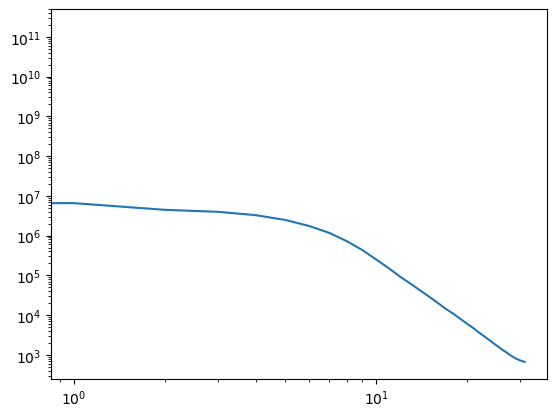

In [10]:
fig, ax = plt.subplots()
ax.loglog(avg_psd)